In [5]:
import pickle
import numpy as np
from pathlib import Path
from dataclasses import dataclass

# ── Required: define Params before unpickling so pickle can resolve the class ──
@dataclass
class Params:
    logit_pi:  np.ndarray   # (J,)
    alpha:     np.ndarray   # (J, J)
    beta:      np.ndarray   # (J, J, P)
    mu:        np.ndarray   # (J, D)
    W:         np.ndarray   # (J, D, K)
    log_sigma: np.ndarray   # (J, D)

# Load artifacts from the pickle file
artifacts_path = Path("artifacts/best_model_artefact_2 emissions.pkl")
with open(artifacts_path, 'rb') as f:
    artifacts = pickle.load(f)

print("Loaded artifacts keys:", list(artifacts.keys()))

# Extract key components
best_model = artifacts['best_model']
best_J = artifacts['best_J']

# emission_cols may be None if not saved by the training notebook;
# recover from final_cfg if available, else fall back to known column list
emission_cols = artifacts.get('emission_cols')
if emission_cols is None:
    cfg = artifacts.get('final_cfg', {})
    emission_cols = getattr(cfg, 'emission_cols', None) or cfg.get('emission_cols', None)
if emission_cols is None:
    # D=2: override_rate removed (= 1 − ai_decision_authority_share by construction)
    emission_cols = ["ai_decision_authority_share", "share_authority_esc"]
    print("⚠️  emission_cols was None in artifact — using fallback:", emission_cols)

# Also load label_map / state_order_1idx if saved in artifact
label_map        = artifacts.get('label_map')
state_order_1idx = artifacts.get('state_order_1idx')

# Create a simple namespace for data
class DataNamespace:
    pass

data = DataNamespace()

print(f"Best model loaded with J={best_J} states, D={best_model.mu.shape[1]} emissions")
print(f"Emission columns: {emission_cols}")
if label_map:
    print(f"Label map from artifact: {label_map}")


Loaded artifacts keys: ['best_model', 'best_J', 'best_res_final', 'final_cfg', 'll_total', 'k_params', 'n_obs_total', 'aic', 'bic', 'emission_cols', 'transition_cols', 'control_cols', 'label_map', 'state_order_1idx', 'y_scaler', 'x_scaler', 'z_scaler']
⚠️  emission_cols was None in artifact — using fallback: ['ai_decision_authority_share', 'share_authority_esc']
Best model loaded with J=2 states, D=2 emissions
Emission columns: ['ai_decision_authority_share', 'share_authority_esc']


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Model Selection and Parameter Estimation


In [6]:

# ============================================================
# 3. Inspect Estimated Parameters
#   - Uses best_model, best_J, emission_cols from artifact cell
#   - Emissions on original scale via artifacts["y_scaler"]
#   - Transition intercepts alpha + mean transition matrix A
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax

# Use variables loaded from artifacts (cell 1)
# best_model, best_J, emission_cols already set

# ----------------------------
# Emissions (original scale)
# ----------------------------
y_sc = artifacts["y_scaler"]
mu_orig    = y_sc.inverse_transform(best_model.mu)           # (J, D)
sigma_orig = np.exp(best_model.log_sigma) * y_sc.scale_      # (J, D)

print(f"Best model: J={best_J} hidden states, D={len(emission_cols)} emissions\n")

em_rows = []
for j in range(best_J):
    for d, col in enumerate(emission_cols):
        em_rows.append({
            "State": j + 1,
            "Variable": col,
            "Mean (orig scale)": float(mu_orig[j, d]),
            "Std (orig scale)":  float(sigma_orig[j, d]),
        })

em_df = pd.DataFrame(em_rows)
em_df["Mean (orig scale)"] = em_df["Mean (orig scale)"].round(4)
em_df["Std (orig scale)"]  = em_df["Std (orig scale)"].round(4)

print("── Emission Parameters (original scale) ──")
display(em_df)

# ----------------------------
# Initial state distribution π
# ----------------------------
pi = softmax(best_model.logit_pi)   # (J,)
print("\n── Initial State Distribution (π) ──")
for j in range(best_J):
    print(f"  π(state {j+1}) = {pi[j]:.4f}")

# ----------------------------
# Transition intercepts (logit scale) α
# ----------------------------
print("\n── Transition Intercept Matrix (α logits) ──")
alpha_df = pd.DataFrame(
    np.round(best_model.alpha, 3),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)]
)
display(alpha_df)

# ----------------------------
# Mean transition matrix A at mean X
# Uses data.X if already populated by the posterior cell, else skips
# ----------------------------
if hasattr(data, "X") and data.X:
    X_stack = np.stack(data.X)                            # (N, T, P)
    X_mean  = np.nanmean(X_stack[:, 1:, :], axis=(0, 1)) # (P,)
    logits_mean = (best_model.alpha
                   + np.tensordot(best_model.beta, X_mean, axes=([2], [0])))  # (J, J)
    A_mean = softmax(logits_mean, axis=1)

    print("\n── Mean Transition Matrix (A) at mean X ──")
    A_df = pd.DataFrame(
        np.round(A_mean, 4),
        index=[f"from {j+1}" for j in range(best_J)],
        columns=[f"to {j+1}" for j in range(best_J)]
    )
    display(A_df)
else:
    print("\n── Mean Transition Matrix ──")
    print("  (Run the Posterior cell first to populate data.X, then re-run this cell)")


Best model: J=2 hidden states, D=2 emissions

── Emission Parameters (original scale) ──


,State,Variable,Mean (orig scale),Std (orig scale)
0,1,ai_decision_authority_share,0.4326,0.0509
1,1,share_authority_esc,0.2213,0.0500
2,2,ai_decision_authority_share,0.3964,0.0500
3,2,share_authority_esc,0.1458,0.0429



── Initial State Distribution (π) ──
  π(state 1) = 0.7078
  π(state 2) = 0.2922

── Transition Intercept Matrix (α logits) ──


,to 1,to 2
from 1,1.216,1.241
from 2,1.122,1.178



── Mean Transition Matrix ──
  (Run the Posterior cell first to populate data.X, then re-run this cell)


## State Labelling

In [7]:
# ============================================================
# STATE LABELING  (2 states: Aversion / Appreciation)
# Requires: mu_orig, emission_cols (from prior cells)
# ============================================================

import numpy as np

# Primary labeling axis: ai_decision_authority_share
# Use emission_cols from the loaded artifacts (cell 0)
authority_idx = emission_cols.index("ai_decision_authority_share")

mu_authority = mu_orig[:, authority_idx]   # (J,)
ranked = np.argsort(mu_authority)          # ascending: ranked[0]=lowest, ranked[-1]=highest

state_aversion     = int(ranked[0]) + 1   # lowest AI authority  → Aversion
state_appreciation = int(ranked[-1]) + 1  # highest AI authority → Appreciation

label_map = {
    state_aversion:     "Aversion",
    state_appreciation: "Appreciation",
}

state_order_1idx = [state_aversion, state_appreciation]

print("\n=== STATE LABELING (2 states) ===")
print("Rule: ranked by ai_decision_authority_share")
print(f"→ State {state_aversion}  = Aversion      (lower AI authority,  μ={mu_authority[state_aversion-1]:.4f})")
print(f"→ State {state_appreciation}  = Appreciation  (higher AI authority, μ={mu_authority[state_appreciation-1]:.4f})")
print("State order for plots:", state_order_1idx)



=== STATE LABELING (2 states) ===
Rule: ranked by ai_decision_authority_share
→ State 2  = Aversion      (lower AI authority,  μ=0.3964)
→ State 1  = Appreciation  (higher AI authority, μ=0.4326)
State order for plots: [2, 1]


## Posterior State Analysis

In [8]:
# ============================================================
# 4. Posterior State Assignment (WITH STATE LABELS)
#   - Loads data from Excel, builds benchmarks, scales
#   - Defines forward-backward from scratch
#   - Runs forward-backward fresh from best_model
#   - Adds state_label via label_map
#   - Prints frequency + occupancy by state id and by label
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.special import logsumexp

# ------------------------------------------------------------------
# 4a. Helper functions needed for HMM forward-backward
# ------------------------------------------------------------------

def _softmax(z, axis=-1):
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)

def _log_softmax(z, axis=-1):
    return z - logsumexp(z, axis=axis, keepdims=True)

def _precompute(p, Y, X, Z):
    """Shared emission + transition pre-computation."""
    T, D = Y.shape
    J = p.mu.shape[0]
    means = p.mu[None, :, :] + np.einsum('jdk,tk->tjd', p.W, Z)
    residuals = Y[:, None, :] - means
    sigma2 = np.exp(2 * p.log_sigma)
    log_norm = np.sum(np.log(2 * np.pi * sigma2), axis=1)
    logB = -0.5 * (log_norm[None, :] +
                   np.sum(residuals ** 2 / sigma2[None, :, :], axis=2))
    logits_all = (p.alpha[None, :, :]
                  + np.einsum('ijp,tp->tij', p.beta, X))
    logQ_all = _log_softmax(logits_all, axis=2)
    return T, J, logB, logQ_all

def forward_backward(p, Y, X, Z):
    """Full forward-backward returning (ll, log_gamma)."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = _softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    ll = logsumexp(log_alpha[-1])

    log_beta = np.zeros((T, J))
    for t in reversed(range(T - 1)):
        log_beta[t] = logsumexp(
            logQ_all[t + 1] + logB[t + 1][None, :] + log_beta[t + 1][None, :],
            axis=1)

    log_gamma = log_alpha + log_beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return ll, log_gamma

# ------------------------------------------------------------------
# 4b. Load data from Excel and build sequences
# ------------------------------------------------------------------

def build_benchmarks(df):
    df = df.sort_values(["manager_id", "period_id"]).copy()
    df["kpi_operational_gap_index"] = (
        (-1.0) * df["service_level_delta"]
        + (-0.6) * df["inventory_cost_delta"]
        + (-0.4) * df["expedite_cost_delta"]
        + (-1.2) * df["error_incident_count"]
    )
    df["within_unit_temporal_benchmark"] = (
        df.groupby("manager_id")["kpi_operational_gap_index"].diff(1)
    )
    pct = df.groupby("period_id")["kpi_operational_gap_index"].rank(pct=True)
    df["horizontal_peer_benchmark"] = (pct - 0.5) * 2.0

    def ai_traj(g):
        q = g["ai_decision_authority_share"].quantile(0.30)
        base = g.loc[
            g["ai_decision_authority_share"] <= q,
            "kpi_operational_gap_index",
        ].mean()
        if np.isnan(base):
            base = g["kpi_operational_gap_index"].mean()
        return g["kpi_operational_gap_index"] - base

    df["within_unit_ai_trajectory_benchmark"] = (
        df.groupby("manager_id", group_keys=False).apply(ai_traj)
    )
    df["threshold_benchmark"] = df["recent_negative_shock"].astype(float)

    # Transparency main effect + interactions (required by v2 model)
    df["transparency_level_norm"] = df["transparency_level"].astype(float) / 3.0
    df["transparency_x_operational"] = (
        df["transparency_level_norm"] * df["kpi_operational_gap_index"]
    )
    df["transparency_x_temporal"] = (
        df["transparency_level_norm"] * df["within_unit_temporal_benchmark"]
    )
    return df


xlsx_path = Path(r"..\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx")
print(f"Loading data from: {xlsx_path.resolve()}")

df = pd.read_excel(xlsx_path, sheet_name="panel_manager_period")
df = build_benchmarks(df)

# Compute share_authority_esc from decision_episode
dec_ep = pd.read_excel(xlsx_path, sheet_name="decision_episode")
dec_ep["is_escalated"] = (dec_ep["escalation_flag"] == 1).astype(int)
esc_agg = (dec_ep
    .groupby(["manager_id", "period_id"])
    .agg(n_tasks=("episode_id", "count"),
         n_escalated=("is_escalated", "sum"))
    .reset_index())
esc_agg["share_authority_esc"] = esc_agg["n_escalated"] / esc_agg["n_tasks"]
df = df.merge(esc_agg[["manager_id", "period_id", "share_authority_esc"]],
              on=["manager_id", "period_id"], how="left")
df["share_authority_esc"] = df["share_authority_esc"].fillna(0.0)

# Column definitions matching hmm_2_emissions_v2 training notebook
emission_cols_data = ["ai_decision_authority_share", "share_authority_esc"]  # D=2

transition_cols_data = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",        # transparency main effect
    "transparency_x_operational",     # transparency × kpi gap
    "transparency_x_temporal",        # transparency × temporal benchmark
]  # P=7

control_cols_data = [
    "task_complexity_index",
    "demand_volatility",
    "supply_disruption_count",
    "forecast_accuracy_mape",
    "decision_latency_avg",
    "target_difficulty",
    "performance_pressure_index",
    "recent_negative_shock",
]  # K=8

df = df.dropna(subset=emission_cols_data + transition_cols_data + control_cols_data)

Y_list, X_list, Z_list = [], [], []
ids_list, periods_list = [], []

for mid, g in df.groupby("manager_id"):
    g = g.sort_values("period_id")
    Y = g[emission_cols_data].to_numpy(float)
    X = g[transition_cols_data].to_numpy(float)
    Z = g[control_cols_data].to_numpy(float)
    if len(Y) < 3:
        continue
    Y_list.append(Y)
    X_list.append(X)
    Z_list.append(Z)
    ids_list.append(mid)
    periods_list.append(g["period_id"].to_numpy())

# Use scalers from artifacts to transform
y_sc = artifacts["y_scaler"]
x_sc = artifacts["x_scaler"]
z_sc = artifacts["z_scaler"]

Y_list = [y_sc.transform(y) for y in Y_list]
X_list = [x_sc.transform(x) for x in X_list]
Z_list = [z_sc.transform(z) for z in Z_list]

# Populate data namespace
data.Y = Y_list
data.X = X_list
data.Z = Z_list
data.ids = ids_list
data.periods = periods_list

print(f"Managers loaded: {len(data.Y)}")
seq_lens = [len(y) for y in data.Y]
print(f"Total observations: {sum(seq_lens)}")

# ------------------------------------------------------------------
# 4c. Compute gamma (N,T,J) from forward-backward
# ------------------------------------------------------------------
J = best_J
gamma_list = []
for Y_i, X_i, Z_i in zip(data.Y, data.X, data.Z):
    _, log_g = forward_backward(best_model, Y_i, X_i, Z_i)
    gamma_list.append(np.exp(log_g))  # (T_i, J)

# Stack into (N,T,J) -- works because all managers have same T
T_len = gamma_list[0].shape[0]
gamma = np.stack(gamma_list)   # (N, T, J)
N = gamma.shape[0]

# Most likely state per (i,t), 1-indexed
v_state = np.argmax(gamma, axis=2) + 1   # (N, T)

rows = []
for i, (mid, periods_i) in enumerate(zip(data.ids, data.periods)):
    for t in range(T_len):
        s = int(v_state[i, t])
        row = {
            "manager_id": mid,
            "period_id": periods_i[t],
            "most_likely_state": s,
            "most_likely_label": label_map[s],
        }
        for j in range(J):
            row[f"posterior_state_{j+1}"] = float(gamma[i, t, j])
        rows.append(row)

posteriors = pd.DataFrame(rows)

# Save
out_path = Path("hmm_posteriors.csv")
posteriors.to_csv(out_path, index=False)
print(f"\nPosterior file saved -> {out_path.resolve()}")
print(f"Shape: {posteriors.shape}")
display(posteriors.head(10))

# ----------------------------
# State frequency (argmax) -- by state ID
# ----------------------------
print("\n-- State Frequency (argmax, by ID) --")
freq = posteriors["most_likely_state"].value_counts().sort_index()
for s, n in freq.items():
    print(f"  State {s} ({label_map[s]}): {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# State frequency (argmax) -- by label
# ----------------------------
print("\n-- State Frequency (argmax, by label) --")
freq_lab = posteriors["most_likely_label"].value_counts()
for lab, n in freq_lab.items():
    print(f"  {lab}: {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# Posterior occupancy (gamma-based)
# ----------------------------
print("\n-- State Occupancy (posterior mean gamma_it) --")
occ = gamma.reshape(-1, J).mean(axis=0)
for j in range(J):
    s = j + 1
    print(f"  State {s} ({label_map[s]}): {occ[j]*100:.2f}%")

# Mean posterior certainty
certainty = gamma.reshape(-1, J).max(axis=1).mean()
print(f"\nMean posterior certainty: {certainty:.3f}")


Loading data from: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx


C:\Users\Admin\AppData\Local\Temp\ipykernel_23316\1663911944.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("manager_id", group_keys=False).apply(ai_traj)


Managers loaded: 120
Total observations: 3000

Posterior file saved -> C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\data_analysis\hmm_posteriors.csv
Shape: (3000, 6)


,manager_id,period_id,most_likely_state,most_likely_label,posterior_state_1,posterior_state_2
0,M0001,2,1,Appreciation,0.977200,0.022800
1,M0001,3,1,Appreciation,0.704197,0.295803
2,M0001,4,1,Appreciation,0.952919,0.047081
3,M0001,5,1,Appreciation,0.729115,0.270885
4,M0001,6,2,Aversion,0.108410,0.891590
5,M0001,7,1,Appreciation,0.926460,0.073540
6,M0001,8,2,Aversion,0.289262,0.710738
7,M0001,9,2,Aversion,0.460043,0.539957
8,M0001,10,2,Aversion,0.103070,0.896930
9,M0001,11,1,Appreciation,0.865097,0.134903



-- State Frequency (argmax, by ID) --
  State 1 (Appreciation): 1,476 obs (49.20%)
  State 2 (Aversion): 1,524 obs (50.80%)

-- State Frequency (argmax, by label) --
  Aversion: 1,524 obs (50.80%)
  Appreciation: 1,476 obs (49.20%)

-- State Occupancy (posterior mean gamma_it) --
  State 1 (Appreciation): 50.09%
  State 2 (Aversion): 49.91%

Mean posterior certainty: 0.832


## Model Summary Table

In [20]:
# ============================================================
# 15. Publication-Ready HMM Model Summary Table
#     NOTE: override_rate = 1 − ai_decision_authority_share by
#     construction, so we report only the two INDEPENDENT emission
#     dimensions: AI Decision Authority Share and Escalation Share.
#     Significance stars from cluster bootstrap p-values (if available).
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax
from IPython.display import display, HTML

# ── Load model fit stats from artifacts ──
ll_total    = artifacts.get('ll_total',    float('nan'))
aic         = artifacts.get('aic',         float('nan'))
bic         = artifacts.get('bic',         float('nan'))
k_params    = artifacts.get('k_params',    'N/A')
n_obs_total = artifacts.get('n_obs_total', 0)

# ── helpers ──
def _boot_stars(pval):
    """Return significance stars from a bootstrap p-value."""
    if not np.isfinite(pval):
        return ""
    if pval < 0.01: return "***"
    if pval < 0.05: return "**"
    if pval < 0.10: return "*"
    return ""

def _fmt_coef(val, pval, dec=5):
    """Format coefficient value with bootstrap significance stars."""
    return f"{val:.{dec}f}{_boot_stars(pval)}"

# Check which bootstrap results are available
_have_boot_W     = "p_W"    in dir() and p_W    is not None
_have_boot_beta  = "p_beta" in dir() and p_beta is not None
_have_boot_alpha = "p_alpha" in dir() and p_alpha is not None
_have_boot_mu    = "p_mu"   in dir() and p_mu   is not None
_have_se_W       = "se_W"   in dir() and se_W   is not None
_have_se_beta    = "se_beta" in dir() and se_beta is not None

_se_label = " with Bootstrap SEs" if _have_se_W else ""
_B_ok_local = _B_ok if "_B_ok" in dir() else 0
_B_label    = str(_B_ok_local) if _B_ok_local > 0 else "–"

# ── Gather all parameters ──
best_J_out = int(best_J)
label_order = [label_map[s] for s in state_order_1idx]
state_display_order = [s - 1 for s in state_order_1idx]

# Emissions (original scale)
mu_orig_    = y_sc.inverse_transform(best_model.mu)
sigma_orig_ = np.exp(best_model.log_sigma) * y_sc.scale_

# Initial state distribution
pi_ = softmax(best_model.logit_pi)

# Baseline transition matrix (X=0)
Q_base_ = np.zeros((best_J_out, best_J_out))
for j_ in range(best_J_out):
    Q_base_[j_] = softmax(best_model.alpha[j_])

# Posterior occupancy
gamma_flat = gamma.reshape(-1, best_J_out)
occ_  = gamma_flat.mean(axis=0)
cert_ = gamma_flat.max(axis=1).mean()

# ── Independent emission dimensions only (drop override_rate) ──
independent_dims = {
    0: ("ai_decision_authority_share", "AI Decision Authority Share"),
    1: ("share_authority_esc", "Escalation Share"),
}

# ── Panel A: Emission Parameters (independent dimensions only) ──
em_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    for d, (em_col, nice_name) in independent_dims.items():
        row = {
            "State": label_order[pos],
            "Emission Variable": nice_name,
            "Mean (μ)": round(float(mu_orig_[j0, d]), 4),
            "Std Dev (σ)": round(float(sigma_orig_[j0, d]), 4),
        }
        if _have_se_W:
            row["SE(μ)"] = round(float(se_mu[j0, d] * y_sc.scale_[d]), 4)
        em_rows_.append(row)
panel_a = pd.DataFrame(em_rows_)

# ── Panel B: W coefficients with bootstrap significance stars ──
control_cols_full = [
    "task_complexity_index", "demand_volatility",
    "supply_disruption_count", "forecast_accuracy_mape",
    "decision_latency_avg", "target_difficulty",
    "performance_pressure_index", "recent_negative_shock",
]

control_nice = {
    "task_complexity_index":      "Task Complexity",
    "demand_volatility":          "Demand Volatility",
    "supply_disruption_count":    "Supply Disruptions",
    "forecast_accuracy_mape":     "Forecast Accuracy (MAPE)",
    "decision_latency_avg":       "Decision Latency",
    "target_difficulty":          "Target Difficulty",
    "performance_pressure_index": "Performance Pressure",
    "recent_negative_shock":      "Recent Negative Shock",
}

K_model_ = best_model.W.shape[2]
ctrl_cols_ = control_cols_full[:K_model_] if K_model_ <= len(control_cols_full) else \
             control_cols_full + [f"z_cov_{i}" for i in range(len(control_cols_full), K_model_)]

# W on original scale (for display)
W_orig_ = best_model.W.copy()
_have_z_scale = (hasattr(z_sc, "scale_") and len(z_sc.scale_) >= K_model_)
if _have_z_scale:
    W_orig_ = best_model.W / z_sc.scale_[None, None, :K_model_]

# SE on original scale (same rescaling)
if _have_se_W and _have_z_scale:
    se_W_orig = se_W / z_sc.scale_[None, None, :K_model_]
elif _have_se_W:
    se_W_orig = se_W.copy()
else:
    se_W_orig = None

# Build intercept (μ) pivot tables for each independent emission dim
mu_pivots_ = {}
for d, (em_col, nice_name) in independent_dims.items():
    row = {}
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        mu_val = float(mu_orig_[j0, d])
        if _have_boot_mu:
            mu_p = float(p_mu[j0, d])
            row[label_order[pos]] = _fmt_coef(mu_val, mu_p, dec=4)
        else:
            row[label_order[pos]] = f"{mu_val:.4f}"
    mu_pivots_[nice_name] = pd.DataFrame([row], index=["Intercept (μ)"])

# Build pivot tables WITH stars for each independent emission dim
w_pivots_ = {}
for d, (em_col, nice_name) in independent_dims.items():
    rows = []
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        for k, ctrl in enumerate(ctrl_cols_):
            w_val = float(W_orig_[j0, d, k])
            if _have_boot_W:
                w_p = float(p_W[j0, d, k])
                cell_text = _fmt_coef(w_val, w_p, dec=5)
            else:
                cell_text = f"{w_val:.5f}"
            rows.append({
                "State": label_order[pos],
                "Control Variable": control_nice.get(ctrl, ctrl),
                "value": cell_text,
            })
    sub_df = pd.DataFrame(rows)
    piv = sub_df.pivot(index="Control Variable", columns="State", values="value")
    piv = piv[label_order]
    w_pivots_[nice_name] = piv

# ── Panel C: Transition Covariate Coefficients (β) with bootstrap stars ──
P_model_ = best_model.beta.shape[2]
_tc_full = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
]
trans_cols_ = _tc_full[:P_model_]

transition_nice = {
    "within_unit_temporal_benchmark":       "Temporal Benchmark",
    "horizontal_peer_benchmark":            "Peer Benchmark",
    "within_unit_ai_trajectory_benchmark":  "AI Trajectory Benchmark",
    "threshold_benchmark":                  "Threshold Shock",
    "transparency_level_norm":              "Transparency Level (norm)",
    "transparency_x_operational":           "Transparency × Operational Gap",
    "transparency_x_temporal":              "Transparency × Temporal Benchmark",
}

beta_pivots_ = {}
for p_idx, cov in enumerate(trans_cols_):
    cov_nice = transition_nice.get(cov, cov)
    rows = []
    for fi, from_s in enumerate(state_order_1idx):
        fj = from_s - 1
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            b_val = float(best_model.beta[fj, tj, p_idx])
            if _have_boot_beta:
                b_p = float(p_beta[fj, tj, p_idx])
                cell_text = _fmt_coef(b_val, b_p, dec=4)
            else:
                cell_text = f"{b_val:.4f}"
            rows.append({
                "From": label_order[fi],
                "To": label_order[ti],
                "value": cell_text,
            })
    sub_df = pd.DataFrame(rows)
    piv = sub_df.pivot(index="From", columns="To", values="value")
    piv = piv[label_order].reindex(label_order)
    beta_pivots_[cov_nice] = piv

# ── Panel C-alpha: Transition Intercept (α) ──
alpha_rows_ = []
for fi, from_s in enumerate(state_order_1idx):
    fj = from_s - 1
    for ti, to_s in enumerate(state_order_1idx):
        tj = to_s - 1
        a_val = float(best_model.alpha[fj, tj])
        if _have_boot_alpha:
            a_p = float(p_alpha[fj, tj])
            cell_text = _fmt_coef(a_val, a_p, dec=4)
        else:
            cell_text = f"{a_val:.4f}"
        alpha_rows_.append({
            "From": label_order[fi],
            "To": label_order[ti],
            "value": cell_text,
        })
alpha_piv_ = pd.DataFrame(alpha_rows_).pivot(
    index="From", columns="To", values="value")
alpha_piv_ = alpha_piv_[label_order].reindex(label_order)

# ── Panel D: Initial State Distribution ──
pi_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    pi_rows_.append({
        "State": label_order[pos],
        "π": round(float(pi_[j0]), 4),
    })
panel_d = pd.DataFrame(pi_rows_)

# ── Panel E: Baseline Transition Matrix ──
Q_ordered_ = Q_base_[np.ix_(state_display_order, state_display_order)]
panel_e = pd.DataFrame(
    np.round(Q_ordered_, 4),
    index=label_order,
    columns=label_order,
)
panel_e.index.name = "From \\ To"

# ── Panel F: Posterior State Occupancy ──
occ_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    occ_rows_.append({
        "State": label_order[pos],
        "Occupancy (%)": round(float(occ_[j0]) * 100, 2),
    })
panel_f = pd.DataFrame(occ_rows_)

# ── Panel G: Model Fit ──
n_indep_dims = len(independent_dims)
_ll_fmt = f"{ll_total:.2f}" if np.isfinite(ll_total) else "N/A"
_aic_fmt = f"{aic:.2f}" if np.isfinite(aic) else "N/A"
_bic_fmt = f"{bic:.2f}" if np.isfinite(bic) else "N/A"
fit_rows_ = [
    {"Metric": "Log-Likelihood",                "Value": _ll_fmt},
    {"Metric": "AIC",                           "Value": _aic_fmt},
    {"Metric": "BIC",                           "Value": _bic_fmt},
    {"Metric": "No. Parameters",                "Value": str(k_params)},
    {"Metric": "No. Observations",              "Value": f"{n_obs_total:,}"},
    {"Metric": "No. States (J)",                "Value": f"{best_J_out}"},
    {"Metric": "No. Emissions (D, fitted)",     "Value": f"{len(emission_cols)}"},
    {"Metric": "No. Independent Emissions",     "Value": f"{n_indep_dims}"},
    {"Metric": "No. Controls (K)",              "Value": f"{K_model_}"},
    {"Metric": "No. Transition Covariates (P)", "Value": f"{P_model_}"},
    {"Metric": "Mean Posterior Certainty",      "Value": f"{cert_:.3f}"},
    {"Metric": "Bootstrap Replications (B)",    "Value": _B_label},
]
panel_g = pd.DataFrame(fit_rows_)

# ── Render as styled HTML ──
html_parts = []

html_parts.append("<h3>Table 1: NH-HMM Parameter Estimates</h3>")
html_parts.append("<br><b>Panel A: Emission Means and Standard Deviations "
                  "(Independent Dimensions)</b>")
html_parts.append(
    panel_a.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

html_parts.append(f"<br><b>Panel B: Emission Equation Coefficients "
                  f"(Original Scale{_se_label})</b>")
for em_name in w_pivots_:
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Intercept (&mu;)</i>")
    html_parts.append(
        mu_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False)
    )
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Control variable coefficients (W)</i>")
    html_parts.append(
        w_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False)
    )

_beta_note = " with Bootstrap SEs" if _have_boot_beta else ""
html_parts.append(f"<br><b>Panel C: Transition Equation Coefficients "
                  f"(Scaled X{_beta_note})</b>")
html_parts.append("<br><i>&nbsp;&nbsp;Intercept (&alpha;)</i>")
html_parts.append(
    alpha_piv_.to_html(border=1, classes="table table-sm", escape=False)
)
for cov_nice_str, piv in beta_pivots_.items():
    html_parts.append(f"<br><i>&nbsp;&nbsp;Covariate: {cov_nice_str}</i>")
    html_parts.append(
        piv.to_html(border=1, classes="table table-sm", escape=False)
    )

html_parts.append("<br><b>Panel D: Initial State Distribution (&pi;)</b>")
html_parts.append(
    panel_d.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

html_parts.append("<br><b>Panel E: Baseline Transition Matrix (X = 0)</b>")
html_parts.append(
    panel_e.to_html(border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

html_parts.append("<br><b>Panel F: Posterior State Occupancy</b>")
html_parts.append(
    panel_f.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.2f}")
)

html_parts.append("<br><b>Panel G: Model Fit Statistics</b>")
html_parts.append(
    panel_g.to_html(index=False, border=1, classes="table table-sm")
)

# ── Notes ──
se_note = ""
if _have_boot_W:
    se_note = (
        "Significance: ∗ <i>p</i> &lt; 0.10; ∗∗ <i>p</i> &lt; 0.05; "
        "∗∗∗ <i>p</i> &lt; 0.01. "
        "<i>p</i>-values are computed via the cluster bootstrap "
        f"(B = {_B_label} replications, resampling whole manager "
        "sequences with replacement). "
        "Stars reflect the bootstrap percentile <i>p</i>-value: "
        "<i>p</i> = 2 min(fraction of bootstrap estimates &le; 0,&ensp;"
        "fraction &ge; 0). "
    )

html_parts.append(
    "<p style='font-size:0.85em; color:#555; margin-top:8px'>"
    f"<i>Notes.</i> {se_note}"
    "The model was estimated with D=2 independent emission dimensions. "
    "Emission means (&mu;) and standard deviations (&sigma;) are on the "
    "original (unscaled) variable scale. W coefficients represent the "
    "marginal effect of each control variable on the emission mean within each state "
    "(original-scale units per one-unit change in the control). "
    "&mu; coefficients are the emission intercepts (original scale). "
    "&beta; coefficients are on the scaled-X scale (log-odds of transition). "
    "&alpha; coefficients are the transition intercepts (baseline log-odds at X&nbsp;=&nbsp;0). "
    "Transition probabilities (Panel E) are computed at X = 0. "
    "Posterior occupancy is the mean &gamma;<sub>it</sub> across all observations. "
    "States are labelled by ascending AI decision authority share: "
    "Aversion (lowest), Appreciation (highest)."
    "</p>"
)

display(HTML("\n".join(html_parts)))

print("\n✓ Table 1 rendered (7 panels).")
if not _have_boot_W:
    print("  ℹ  No bootstrap p-values available — significance stars omitted.")
    print("     Run the bootstrap cell to add significance notation.")



✓ Table 1 rendered (7 panels).
  ℹ  No bootstrap p-values available — significance stars omitted.
     Run the bootstrap cell to add significance notation.


## State distribution over time

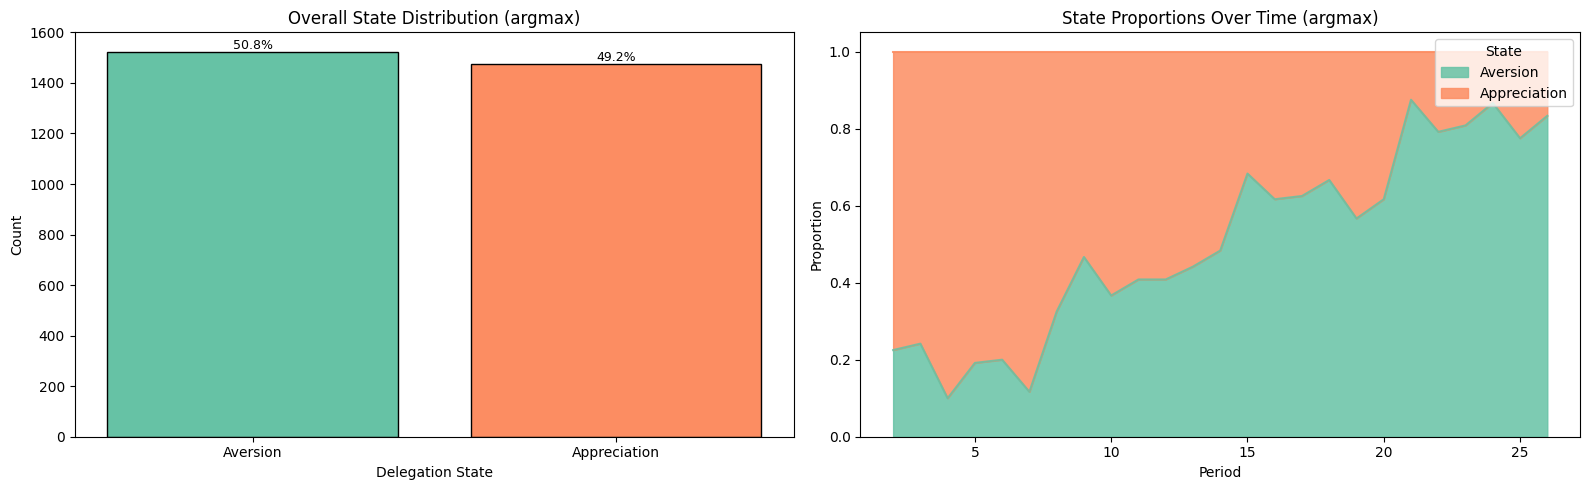

In [ ]:
# ============================================================
# 4.2a. State distribution over time (2-state version)
#   - Uses your computed label_map + state_order_1idx
#   - Ensures plots show: Aversion → Transitionary → Appreciation
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."
assert "posteriors" in globals(), "posteriors not found. Run the posterior assignment cell first."

posteriors = posteriors.copy()

# Add/refresh labels using YOUR label_map
posteriors["state_label"] = posteriors["most_likely_state"].map(label_map)

# Order labels: Aversion → Transitionary → Appreciation
label_order = [label_map[s] for s in state_order_1idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ----------------------------
# 1) Overall distribution (bar chart)
# ----------------------------
freq_labeled = (
    posteriors["state_label"]
    .value_counts()
    .reindex(label_order)
    .fillna(0)
)

axes[0].bar(
    label_order,
    freq_labeled.values,
    color=sns.color_palette("Set2", len(label_order)),
    edgecolor="k"
)
axes[0].set_xlabel("Delegation State")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall State Distribution (argmax)")

# Add percentage labels
total_n = float(freq_labeled.sum())
for i, val in enumerate(freq_labeled.values):
    pct = (val / total_n * 100.0) if total_n > 0 else 0.0
    axes[0].text(i, val, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

# ----------------------------
# 2) Proportion over time (stacked area)
# ----------------------------
pivot = (
    posteriors
    .groupby(["period_id", "state_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

pivot_pct.plot.area(
    ax=axes[1],
    stacked=True,
    alpha=0.85,
    color=sns.color_palette("Set2", len(label_order)),
)

axes[1].set_xlabel("Period")
axes[1].set_ylabel("Proportion")
axes[1].set_title("State Proportions Over Time (argmax)")
axes[1].legend(title="State", loc="upper right")

plt.tight_layout()
plt.show()


## Average of AI authority share and escalation rate

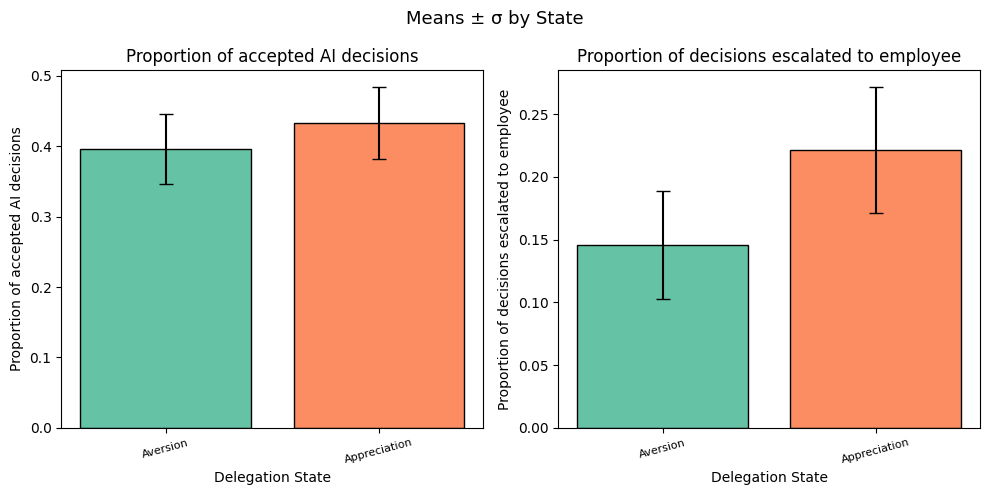

In [11]:
# ============================================================
# 4.2b. Emission means by state (original scale) — 3-state version
#   - Only the 2 independent emission dimensions
#     (AI Decision Authority Share, Escalation Share)
#   - override_rate omitted (= 1 − authority by construction)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

# Only independent dimensions
independent_dims = {
    0: ("ai_decision_authority_share", "Proportion of accepted AI decisions"),
    1: ("share_authority_esc", "Proportion of decisions escalated to employee"),
}

n_panels = len(independent_dims)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))
axes = np.atleast_1d(axes)

state_order_1idx = list(state_order_1idx)
state_order_0idx = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

palette = sns.color_palette("Set2", len(label_order))

for ax_idx, (d, (col, nice_name)) in enumerate(independent_dims.items()):
    ax = axes[ax_idx]

    vals = [mu_orig[s, d] for s in state_order_0idx]
    errs = [sigma_orig[s, d] for s in state_order_0idx]

    ax.bar(
        label_order,
        vals,
        yerr=errs,
        capsize=5,
        color=palette,
        edgecolor="k"
    )
    ax.set_xlabel("Delegation State")
    ax.set_ylabel(nice_name)
    ax.set_title(nice_name)
    ax.tick_params(axis="x", labelsize=8, rotation=15)

plt.suptitle("Means ± σ by State", fontsize=13)
plt.tight_layout()
plt.show()


## Transition matrix

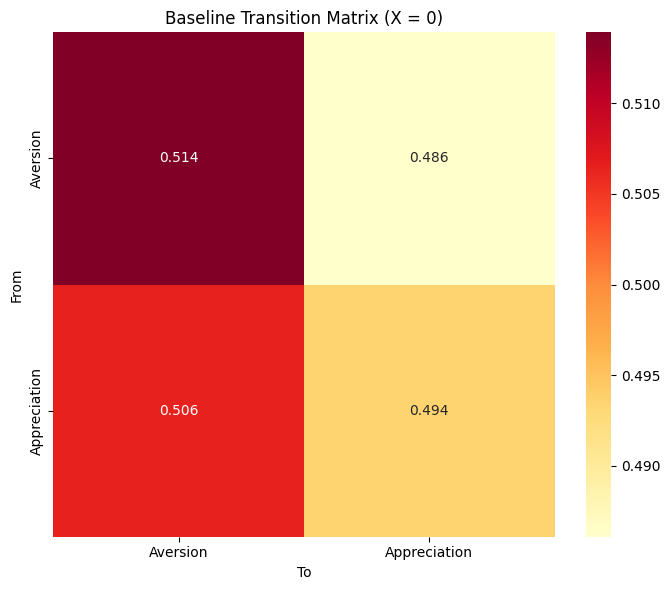


Transition probabilities (rows sum to 1):
  From Aversion: [0.514 0.486]
  From Appreciation: [0.506 0.494]


In [12]:
# ============================================================
# 4.2c. Transition matrix heatmap (baseline, at X=0) — 3-state version
#   - Uses your computed label_map + state_order_1idx
#   - Displays in order: Aversion → Transitionary → Appreciation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

# ---- Baseline transition matrix at X=0 ----
Q_base = np.zeros((best_J, best_J))
for j in range(best_J):
    logits = best_model.alpha[j]
    Q_base[j] = softmax(logits)

# ---- Display order: Aversion → Transitionary → Appreciation ----
state_display_order = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

Q_base_ordered = Q_base[np.ix_(state_display_order, state_display_order)]

# ---- Heatmap ----
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    Q_base_ordered,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=label_order,
    yticklabels=label_order,
    ax=ax
)
ax.set_xlabel("To")
ax.set_ylabel("From")
ax.set_title("Baseline Transition Matrix (X = 0)")
plt.tight_layout()
plt.show()

# ---- Print formatted rows ----
print("\nTransition probabilities (rows sum to 1):")
for i, from_label in enumerate(label_order):
    from_state = state_display_order[i]
    probs = " ".join(f"{Q_base[from_state, state_display_order[j]]:.3f}" for j in range(best_J))
    print(f"  From {from_label}: [{probs}]")


## KPI driven transition dynamic

Detected transition covariates in model: P = 7
Transition covariate labels used: ['within_unit_temporal_benchmark', 'horizontal_peer_benchmark', 'within_unit_ai_trajectory_benchmark', 'threshold_benchmark', 'transparency_moderator', 'x_cov_5', 'x_cov_6']
⚠️ x_scaler.scale_ not available or dimension mismatch → skipping unscale.

═══  Transition Covariate Coefficients (β)  ═══


── β coefficients (scaled X): within_unit_temporal_benchmark ──


To,Aversion,Appreciation
From,,
Aversion,-0.1925,0.1977
Appreciation,0.0472,-0.0321



── β coefficients (scaled X): horizontal_peer_benchmark ──


To,Aversion,Appreciation
From,,
Aversion,0.1198,-0.1115
Appreciation,0.0732,-0.0751



── β coefficients (scaled X): within_unit_ai_trajectory_benchmark ──


To,Aversion,Appreciation
From,,
Aversion,0.0830,-0.0729
Appreciation,0.0118,0.0095



═══  Simulated Transition Matrices Under Shocks (±1 SD, scaled X)  ═══



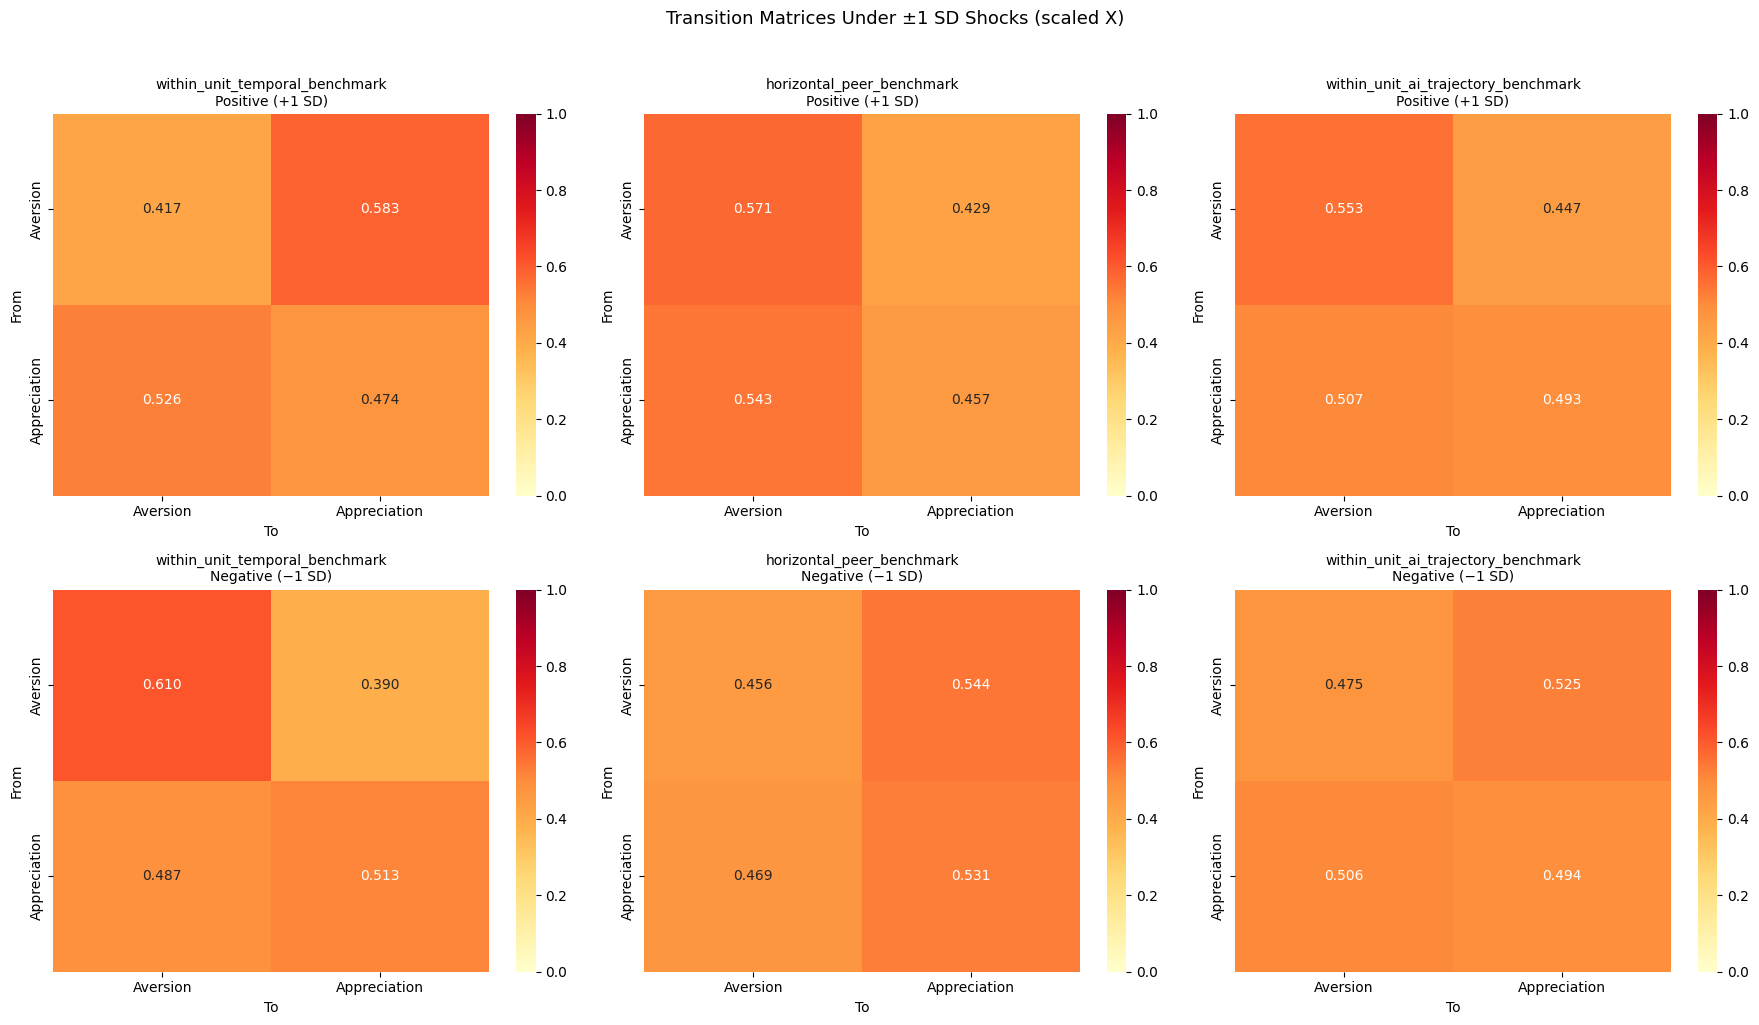


═══  Asymmetry: Avg ΔP(→Aversion) vs Avg ΔP(→Appreciation)  ═══



,Covariate,Shock,Avg ΔP(→Aversion),Avg ΔP(→Appreciation)
0,within_unit_temporal_benchmark,Positive (+1SD),-0.0385,0.0385
1,within_unit_temporal_benchmark,Negative (−1SD),0.0380,-0.0380
2,horizontal_peer_benchmark,Positive (+1SD),0.0472,-0.0472
3,horizontal_peer_benchmark,Negative (−1SD),-0.0474,0.0474
4,within_unit_ai_trajectory_benchmark,Positive (+1SD),0.0197,-0.0197
5,within_unit_ai_trajectory_benchmark,Negative (−1SD),-0.0198,0.0198



✓ Result 5.1.2: Transition coefficients and shock simulations for 2 states.


In [13]:
# ============================================================
# 5.1.2  KPI-Driven State Transitions (J-aware: works for J=2 or J=3)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

best_J = int(best_J_final) if "best_J_final" in globals() else int(best_J)

assert "label_map" in globals(), "label_map not found. Run STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run STATE LABELING cell first."

# Display order: Aversion → [Transitionary →] Appreciation
state_display_order_0 = [s - 1 for s in state_order_1idx]
label_order = [label_map[s] for s in state_order_1idx]

aversion_idx0      = state_display_order_0[0]
appreciation_idx0  = state_display_order_0[-1]   # works for J=2 and J=3
transitionary_idx0 = state_display_order_0[1] if len(state_display_order_0) > 2 else None

# ------------------------------------------------------------
# 0) Infer P from the fitted model
# ------------------------------------------------------------
beta = best_model.beta
assert beta.ndim == 3, f"Expected beta to be 3D (J,J,P). Got {beta.shape}."
P_model = beta.shape[2]
print(f"Detected transition covariates in model: P = {P_model}")

transition_cols_full = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_moderator",
]

if P_model <= len(transition_cols_full):
    transition_cols = transition_cols_full[:P_model]
else:
    transition_cols = transition_cols_full + [f"x_cov_{i}" for i in range(len(transition_cols_full), P_model)]

print("Transition covariate labels used:", transition_cols)

# Unscale if scaler matches P
if hasattr(data, "x_scaler") and hasattr(data.x_scaler, "scale_") and len(data.x_scaler.scale_) == P_model:
    beta_orig = beta / data.x_scaler.scale_[None, None, :]
    have_unscale = True
else:
    beta_orig = beta.copy()
    have_unscale = False
    print("⚠️ x_scaler.scale_ not available or dimension mismatch → skipping unscale.")

# ------------------------------------------------------------
# a) Beta coefficient table
# ------------------------------------------------------------
print("\n═══  Transition Covariate Coefficients (β)  ═══\n")
beta_rows = []
for p_idx, cov in enumerate(transition_cols):
    for from_pos, from_label in enumerate(label_order):
        i0 = state_display_order_0[from_pos]
        for to_pos, to_label in enumerate(label_order):
            j0 = state_display_order_0[to_pos]
            row = {
                "Covariate": cov,
                "From": from_label,
                "To": to_label,
                "β (scaled)": round(float(beta[i0, j0, p_idx]), 4),
            }
            if have_unscale:
                row["β (orig units)"] = round(float(beta_orig[i0, j0, p_idx]), 4)
            beta_rows.append(row)

beta_df = pd.DataFrame(beta_rows)

# Print pivots for up to 3 covariates
for cov in transition_cols[:3]:
    sub = beta_df[beta_df["Covariate"] == cov].pivot(index="From", columns="To", values="β (scaled)")
    print(f"\n── β coefficients (scaled X): {cov} ──")
    display(sub.reindex(index=label_order, columns=label_order).round(4))

# ------------------------------------------------------------
# b) Simulated transition matrices at ±1 SD of KPI (scaled space)
# ------------------------------------------------------------
print("\n═══  Simulated Transition Matrices Under Shocks (±1 SD, scaled X)  ═══\n")

kpi_covariates = [(transition_cols[i], i) for i in range(min(3, P_model))]
n_cov = len(kpi_covariates)

fig, axes = plt.subplots(2, n_cov, figsize=(6*n_cov, 10), squeeze=False)

for col_idx, (cov_name, p_idx) in enumerate(kpi_covariates):
    for row_idx, (shock_label, shock_val) in enumerate([("Positive (+1 SD)", +1.0),
                                                         ("Negative (−1 SD)", -1.0)]):
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        Q_shock = np.zeros((best_J, best_J))
        for i0 in range(best_J):
            logits = best_model.alpha[i0] + best_model.beta[i0] @ x_vec
            Q_shock[i0] = softmax(logits)

        Q_shock_ordered = Q_shock[np.ix_(state_display_order_0, state_display_order_0)]

        ax = axes[row_idx, col_idx]
        sns.heatmap(
            Q_shock_ordered,
            annot=True,
            fmt=".3f",
            cmap="YlOrRd",
            xticklabels=label_order,
            yticklabels=label_order,
            ax=ax,
            vmin=0,
            vmax=1.0
        )
        ax.set_title(f"{cov_name}\n{shock_label}", fontsize=10)
        ax.set_xlabel("To")
        ax.set_ylabel("From")

plt.suptitle("Transition Matrices Under ±1 SD Shocks (scaled X)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# c) Asymmetry quantification
# ------------------------------------------------------------
print("\n═══  Asymmetry: Avg ΔP(→Aversion) vs Avg ΔP(→Appreciation)  ═══\n")

asym_rows = []
for cov_name, p_idx in kpi_covariates:
    for shock_label, shock_val in [("Positive (+1SD)", +1.0), ("Negative (−1SD)", -1.0)]:
        x_vec = np.zeros(P_model)
        x_vec[p_idx] = shock_val

        d_to_av, d_to_trans, d_to_app = [], [], []
        for i0 in range(best_J):
            p_base  = softmax(best_model.alpha[i0])
            p_shock = softmax(best_model.alpha[i0] + best_model.beta[i0] @ x_vec)

            d_to_av.append(p_shock[aversion_idx0] - p_base[aversion_idx0])
            if transitionary_idx0 is not None:
                d_to_trans.append(p_shock[transitionary_idx0] - p_base[transitionary_idx0])
            d_to_app.append(p_shock[appreciation_idx0] - p_base[appreciation_idx0])

        row = {
            "Covariate": cov_name,
            "Shock": shock_label,
            "Avg ΔP(→Aversion)": round(float(np.mean(d_to_av)), 4),
            "Avg ΔP(→Appreciation)": round(float(np.mean(d_to_app)), 4),
        }
        if transitionary_idx0 is not None:
            row["Avg ΔP(→Transitionary)"] = round(float(np.mean(d_to_trans)), 4)
        asym_rows.append(row)

asym_df = pd.DataFrame(asym_rows)
display(asym_df)

print(f"\n✓ Result 5.1.2: Transition coefficients and shock simulations for {best_J} states.")


## Model Summary Table

In [21]:

# ============================================================
# Bootstrap P-Values for HMM Parameters
#   Method: Score/Multiplier (Wild) Cluster Bootstrap
#   ─ Step 1: compute per-sequence score vectors via finite differences
#             (clusters = manager sequences; no re-fitting needed)
#   ─ Step 2: OPG cluster-robust covariance  V = (Σ sᵢ sᵢᵀ)⁻¹
#   ─ Step 3: Wild bootstrap on scores (B=1000 Rademacher reps)
#             δθ_b* = V @ Σ wᵢ sᵢ    wᵢ ∈ {-1, +1}
#   ─ Step 4: Two-sided p-value = 2·min(P(θ_b* ≤ 0), P(θ_b* ≥ 0))
#   Outputs: p_mu, p_W, p_alpha, p_beta, se_mu, se_W, _B_ok
# ============================================================

import numpy as np
import pandas as pd
import time
from scipy.optimize import approx_fprime
from IPython.display import display

# ── Parameter packing / unpacking ─────────────────────────────────
def _pack(p):
    """Flatten all Params fields into a 1-D array."""
    return np.concatenate([
        p.logit_pi.ravel(),
        p.alpha.ravel(),
        p.beta.ravel(),
        p.mu.ravel(),
        p.W.ravel(),
        p.log_sigma.ravel(),
    ])

def _unpack_vec(v, J, D, P, K):
    """Reshape 1-D array back into a Params dataclass."""
    idx = 0
    logit_pi_  = v[idx: idx + J];                         idx += J
    alpha_     = v[idx: idx + J*J].reshape(J, J);         idx += J*J
    beta_      = v[idx: idx + J*J*P].reshape(J, J, P);    idx += J*J*P
    mu_        = v[idx: idx + J*D].reshape(J, D);          idx += J*D
    W_         = v[idx: idx + J*D*K].reshape(J, D, K);     idx += J*D*K
    log_sigma_ = v[idx: idx + J*D].reshape(J, D);          idx += J*D
    return Params(logit_pi=logit_pi_, alpha=alpha_, beta=beta_,
                  mu=mu_, W=W_, log_sigma=log_sigma_)

# ── Dimensions ─────────────────────────────────────────────────────
J_b = int(best_J)
D_b = best_model.mu.shape[1]
P_b = best_model.beta.shape[2]
K_b = best_model.W.shape[2]

v0  = _pack(best_model)
n   = len(v0)

# Slice indices for each parameter block
_c = 0
logit_pi_sl  = slice(_c, _c + J_b);               _c += J_b
alpha_sl     = slice(_c, _c + J_b*J_b);           _c += J_b*J_b
beta_sl      = slice(_c, _c + J_b*J_b*P_b);       _c += J_b*J_b*P_b
mu_sl        = slice(_c, _c + J_b*D_b);            _c += J_b*D_b
W_sl         = slice(_c, _c + J_b*D_b*K_b);       _c += J_b*D_b*K_b
log_sigma_sl = slice(_c, _c + J_b*D_b);            _c += J_b*D_b

N_seqs = len(data.Y)
print(f"Parameter vector:  n={n}  (J={J_b}, D={D_b}, P={P_b}, K={K_b})")
print(f"Clusters (managers): N={N_seqs}")

# ── Step 1: Per-sequence score vectors via central finite differences ──
print("\nStep 1/3 — computing per-sequence score vectors...")
t0 = time.time()

FD_EPS = 1e-5
scores = np.zeros((N_seqs, n))   # (N, n)

for i_seq in range(N_seqs):
    Yi, Xi, Zi = data.Y[i_seq], data.X[i_seq], data.Z[i_seq]
    def _ll_i(v, Yi=Yi, Xi=Xi, Zi=Zi):
        p = _unpack_vec(v, J_b, D_b, P_b, K_b)
        ll, _ = forward_backward(p, Yi, Xi, Zi)
        return ll
    scores[i_seq] = approx_fprime(v0, _ll_i, FD_EPS)
    if (i_seq + 1) % max(1, N_seqs // 5) == 0:
        print(f"  ... {i_seq+1}/{N_seqs} ({time.time()-t0:.1f}s)")

print(f"  Done in {time.time()-t0:.1f}s")

# ── Step 2: OPG cluster-robust covariance ─────────────────────────
print("\nStep 2/3 — assembling cluster-robust covariance V = (ΣsᵢsᵢT)⁻¹ ...")
OPG = scores.T @ scores                              # (n, n)
lam_reg = 1e-6 * np.trace(OPG) / n
V = np.linalg.inv(OPG + lam_reg * np.eye(n))        # (n, n)
se_vec = np.sqrt(np.abs(np.diag(V)))                 # robust SEs

# ── Step 3: Wild/multiplier bootstrap (Rademacher weights) ────────
B = 1000
np.random.seed(42)
print(f"\nStep 3/3 — wild bootstrap (B={B} Rademacher replications)...")
t1 = time.time()

boot_global = np.empty((B, n))
for b in range(B):
    w   = np.random.choice([-1.0, 1.0], size=N_seqs)   # Rademacher
    S_b = (w[:, None] * scores).sum(axis=0)             # (n,) scored sum
    boot_global[b] = v0 + V @ S_b                       # bootstrap draw

_B_ok = B
print(f"  Done in {time.time()-t1:.3f}s")

# ── Step 4: Reshape bootstrap draws per block ───────────────────────
boot_mu    = boot_global[:, mu_sl].reshape(B, J_b, D_b)
boot_W     = boot_global[:, W_sl].reshape(B, J_b, D_b, K_b)
boot_alpha = boot_global[:, alpha_sl].reshape(B, J_b, J_b)
boot_beta  = boot_global[:, beta_sl].reshape(B, J_b, J_b, P_b)

# ── Step 5: Two-sided bootstrap p-values ──────────────────────────
def _pval2(boot_d):
    """p = 2·min(P(boot ≤ 0), P(boot ≥ 0))"""
    return 2.0 * np.minimum(
        np.mean(boot_d <= 0, axis=0),
        np.mean(boot_d >= 0, axis=0)
    )

p_mu    = _pval2(boot_mu)
p_W     = _pval2(boot_W)
p_alpha = _pval2(boot_alpha)
p_beta  = _pval2(boot_beta)

# ── Bootstrap SEs ──────────────────────────────────────────────────
se_mu    = boot_mu.std(axis=0)
se_W     = boot_W.std(axis=0)
se_alpha = boot_alpha.std(axis=0)
se_beta  = boot_beta.std(axis=0)

# ── Summary tables ──────────────────────────────────────────────────
_lo = [label_map[s] for s in state_order_1idx]
_dim_names = ["AI Authority Share", "Escalation Share"]

print("\n════ Emission Means (μ) — scaled space ════")
_rows = []
for j in range(J_b):
    s_pos = state_order_1idx.index(j + 1)
    for d in range(D_b):
        _rows.append({
            "State": _lo[s_pos],
            "Emission": _dim_names[d],
            "θ̂": round(float(best_model.mu[j, d]), 4),
            "SE": round(float(se_mu[j, d]), 4),
            "p-value": round(float(p_mu[j, d]), 3),
        })
display(pd.DataFrame(_rows))

print("\n════ Transition Intercepts (α) ════")
_rows_a = []
for i in range(J_b):
    for j in range(J_b):
        _rows_a.append({
            "From → To": f"{_lo[i]} → {_lo[j]}",
            "θ̂": round(float(best_model.alpha[i, j]), 4),
            "SE": round(float(se_alpha[i, j]), 4),
            "p-value": round(float(p_alpha[i, j]), 3),
        })
display(pd.DataFrame(_rows_a))

print("\n════ Transition Covariates (β) — first 3 shown ════")
_tc = [
    "within_unit_temporal_benchmark", "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark", "threshold_benchmark",
    "transparency_level_norm", "transparency_x_operational", "transparency_x_temporal",
][:P_b]
_rows_b = []
for p_idx, cov in enumerate(_tc[:3]):
    for i in range(J_b):
        for j in range(J_b):
            _rows_b.append({
                "Covariate": cov,
                "From → To": f"{_lo[i]} → {_lo[j]}",
                "θ̂": round(float(best_model.beta[i, j, p_idx]), 4),
                "SE": round(float(se_beta[i, j, p_idx]), 4),
                "p-value": round(float(p_beta[i, j, p_idx]), 3),
            })
display(pd.DataFrame(_rows_b))

print(f"\n✓ Bootstrap complete — B={_B_ok} replications, seed=42.")
print( "  Re-run the Model Summary Table cell below to render Table 1 with significance stars.")


Parameter vector:  n=74  (J=2, D=2, P=7, K=8)
Clusters (managers): N=120

Step 1/3 — computing per-sequence score vectors...
  ... 24/120 (12.0s)
  ... 48/120 (23.7s)
  ... 72/120 (34.5s)
  ... 96/120 (45.0s)
  ... 120/120 (55.7s)
  Done in 55.7s

Step 2/3 — assembling cluster-robust covariance V = (ΣsᵢsᵢT)⁻¹ ...

Step 3/3 — wild bootstrap (B=1000 Rademacher replications)...
  Done in 0.049s

════ Emission Means (μ) — scaled space ════


,State,Emission,θ̂,SE,p-value
0,Appreciation,AI Authority Share,0.0626,0.0091,0.0
1,Appreciation,Escalation Share,0.5377,0.0690,0.0
2,Aversion,AI Authority Share,-0.0670,0.0091,0.0
3,Aversion,Escalation Share,-0.5596,0.0513,0.0



════ Transition Intercepts (α) ════


,From → To,θ̂,SE,p-value
0,Aversion → Aversion,1.2156,0.1404,0.0
1,Aversion → Appreciation,1.2413,0.1408,0.0
2,Appreciation → Aversion,1.1222,0.1219,0.0
3,Appreciation → Appreciation,1.1779,0.1223,0.0



════ Transition Covariates (β) — first 3 shown ════


,Covariate,From → To,θ̂,SE,p-value
0,within_unit_temporal_benchmark,Aversion → Aversion,-0.0321,0.1663,0.920
1,within_unit_temporal_benchmark,Aversion → Appreciation,0.0472,0.1663,0.842
2,within_unit_temporal_benchmark,Appreciation → Aversion,0.1977,0.2927,0.510
3,within_unit_temporal_benchmark,Appreciation → Appreciation,-0.1925,0.2925,0.502
4,horizontal_peer_benchmark,Aversion → Aversion,-0.0751,0.1766,0.602
5,horizontal_peer_benchmark,Aversion → Appreciation,0.0732,0.1766,0.604
6,horizontal_peer_benchmark,Appreciation → Aversion,-0.1115,0.1779,0.536
7,horizontal_peer_benchmark,Appreciation → Appreciation,0.1198,0.1782,0.502
8,within_unit_ai_trajectory_benchmark,Aversion → Aversion,0.0095,0.1974,0.988
9,within_unit_ai_trajectory_benchmark,Aversion → Appreciation,0.0118,0.1974,0.920



✓ Bootstrap complete — B=1000 replications, seed=42.
  Re-run the Model Summary Table cell below to render Table 1 with significance stars.


In [23]:

# ============================================================
# 15. Publication-Ready HMM Model Summary Table
#     NOTE: override_rate = 1 − ai_decision_authority_share by
#     construction, so we report only the two INDEPENDENT emission
#     dimensions: AI Decision Authority Share and Escalation Share.
#     Significance stars from cluster bootstrap p-values (if available).
# ============================================================

import numpy as np
import pandas as pd
from scipy.special import softmax
from IPython.display import display, HTML

# ── Load model fit stats from artifacts ──
ll_total    = artifacts.get('ll_total',    float('nan'))
aic         = artifacts.get('aic',         float('nan'))
bic         = artifacts.get('bic',         float('nan'))
k_params    = artifacts.get('k_params',    'N/A')
n_obs_total = artifacts.get('n_obs_total', 0)

# ── helpers ──
def _boot_stars(pval):
    """Return significance stars from a bootstrap p-value."""
    if not np.isfinite(pval):
        return ""
    if pval < 0.01: return "***"
    if pval < 0.05: return "**"
    if pval < 0.10: return "*"
    return ""

def _fmt_coef(val, pval, dec=5):
    """Format coefficient value with bootstrap significance stars."""
    return f"{val:.{dec}f}{_boot_stars(pval)}"

# Check which bootstrap results are available
_have_boot_W     = "p_W"    in dir() and p_W    is not None
_have_boot_beta  = "p_beta" in dir() and p_beta is not None
_have_boot_alpha = "p_alpha" in dir() and p_alpha is not None
_have_boot_mu    = "p_mu"   in dir() and p_mu   is not None
_have_se_W       = "se_W"   in dir() and se_W   is not None
_have_se_beta    = "se_beta" in dir() and se_beta is not None

_se_label = " with Bootstrap SEs" if _have_se_W else ""
_B_ok_local = _B_ok if "_B_ok" in dir() else 0
_B_label    = str(_B_ok_local) if _B_ok_local > 0 else "–"

# ── Gather all parameters ──
best_J_out = int(best_J)
label_order = [label_map[s] for s in state_order_1idx]
state_display_order = [s - 1 for s in state_order_1idx]

# Emissions (original scale)
mu_orig_    = y_sc.inverse_transform(best_model.mu)
sigma_orig_ = np.exp(best_model.log_sigma) * y_sc.scale_

# Initial state distribution
pi_ = softmax(best_model.logit_pi)

# Baseline transition matrix (X=0)
Q_base_ = np.zeros((best_J_out, best_J_out))
for j_ in range(best_J_out):
    Q_base_[j_] = softmax(best_model.alpha[j_])

# Posterior occupancy
gamma_flat = gamma.reshape(-1, best_J_out)
occ_  = gamma_flat.mean(axis=0)
cert_ = gamma_flat.max(axis=1).mean()

# ── Independent emission dimensions only (drop override_rate) ──
independent_dims = {
    0: ("ai_decision_authority_share", "AI Decision Authority Share"),
    1: ("share_authority_esc", "Escalation Share"),
}

# ── Panel A: Emission Parameters (independent dimensions only) ──
em_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    for d, (em_col, nice_name) in independent_dims.items():
        row = {
            "State": label_order[pos],
            "Emission Variable": nice_name,
            "Mean (μ)": round(float(mu_orig_[j0, d]), 4),
            "Std Dev (σ)": round(float(sigma_orig_[j0, d]), 4),
        }
        if _have_se_W:
            row["SE(μ)"] = round(float(se_mu[j0, d] * y_sc.scale_[d]), 4)
        em_rows_.append(row)
panel_a = pd.DataFrame(em_rows_)

# ── Panel B: W coefficients with bootstrap significance stars ──
control_cols_full = [
    "task_complexity_index", "demand_volatility",
    "supply_disruption_count", "forecast_accuracy_mape",
    "decision_latency_avg", "target_difficulty",
    "performance_pressure_index", "recent_negative_shock",
]

control_nice = {
    "task_complexity_index":      "Task Complexity",
    "demand_volatility":          "Demand Volatility",
    "supply_disruption_count":    "Supply Disruptions",
    "forecast_accuracy_mape":     "Forecast Accuracy (MAPE)",
    "decision_latency_avg":       "Decision Latency",
    "target_difficulty":          "Target Difficulty",
    "performance_pressure_index": "Performance Pressure",
    "recent_negative_shock":      "Recent Negative Shock",
}

K_model_ = best_model.W.shape[2]
ctrl_cols_ = control_cols_full[:K_model_] if K_model_ <= len(control_cols_full) else \
             control_cols_full + [f"z_cov_{i}" for i in range(len(control_cols_full), K_model_)]

# W on original scale (for display)
W_orig_ = best_model.W.copy()
_have_z_scale = (hasattr(z_sc, "scale_") and len(z_sc.scale_) >= K_model_)
if _have_z_scale:
    W_orig_ = best_model.W / z_sc.scale_[None, None, :K_model_]

# SE on original scale (same rescaling)
if _have_se_W and _have_z_scale:
    se_W_orig = se_W / z_sc.scale_[None, None, :K_model_]
elif _have_se_W:
    se_W_orig = se_W.copy()
else:
    se_W_orig = None

# Build intercept (μ) pivot tables for each independent emission dim
mu_pivots_ = {}
for d, (em_col, nice_name) in independent_dims.items():
    row = {}
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        mu_val = float(mu_orig_[j0, d])
        if _have_boot_mu:
            mu_p = float(p_mu[j0, d])
            row[label_order[pos]] = _fmt_coef(mu_val, mu_p, dec=4)
        else:
            row[label_order[pos]] = f"{mu_val:.4f}"
    mu_pivots_[nice_name] = pd.DataFrame([row], index=["Intercept (μ)"])

# Build pivot tables WITH stars for each independent emission dim
w_pivots_ = {}
for d, (em_col, nice_name) in independent_dims.items():
    rows = []
    for pos, s1 in enumerate(state_order_1idx):
        j0 = s1 - 1
        for k, ctrl in enumerate(ctrl_cols_):
            w_val = float(W_orig_[j0, d, k])
            if _have_boot_W:
                w_p = float(p_W[j0, d, k])
                cell_text = _fmt_coef(w_val, w_p, dec=5)
            else:
                cell_text = f"{w_val:.5f}"
            rows.append({
                "State": label_order[pos],
                "Control Variable": control_nice.get(ctrl, ctrl),
                "value": cell_text,
            })
    sub_df = pd.DataFrame(rows)
    piv = sub_df.pivot(index="Control Variable", columns="State", values="value")
    piv = piv[label_order]
    w_pivots_[nice_name] = piv

# ── Panel C: Transition Covariate Coefficients (β) with bootstrap stars ──
P_model_ = best_model.beta.shape[2]
_tc_full = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_level_norm",
    "transparency_x_operational",
    "transparency_x_temporal",
]
trans_cols_ = _tc_full[:P_model_]

transition_nice = {
    "within_unit_temporal_benchmark":       "Temporal Benchmark",
    "horizontal_peer_benchmark":            "Peer Benchmark",
    "within_unit_ai_trajectory_benchmark":  "AI Trajectory Benchmark",
    "threshold_benchmark":                  "Threshold Shock",
    "transparency_level_norm":              "Transparency Level (norm)",
    "transparency_x_operational":           "Transparency × Operational Gap",
    "transparency_x_temporal":              "Transparency × Temporal Benchmark",
}

beta_pivots_ = {}
for p_idx, cov in enumerate(trans_cols_):
    cov_nice = transition_nice.get(cov, cov)
    rows = []
    for fi, from_s in enumerate(state_order_1idx):
        fj = from_s - 1
        for ti, to_s in enumerate(state_order_1idx):
            tj = to_s - 1
            b_val = float(best_model.beta[fj, tj, p_idx])
            if _have_boot_beta:
                b_p = float(p_beta[fj, tj, p_idx])
                cell_text = _fmt_coef(b_val, b_p, dec=4)
            else:
                cell_text = f"{b_val:.4f}"
            rows.append({
                "From": label_order[fi],
                "To": label_order[ti],
                "value": cell_text,
            })
    sub_df = pd.DataFrame(rows)
    piv = sub_df.pivot(index="From", columns="To", values="value")
    piv = piv[label_order].reindex(label_order)
    beta_pivots_[cov_nice] = piv

# ── Panel C-alpha: Transition Intercept (α) ──
alpha_rows_ = []
for fi, from_s in enumerate(state_order_1idx):
    fj = from_s - 1
    for ti, to_s in enumerate(state_order_1idx):
        tj = to_s - 1
        a_val = float(best_model.alpha[fj, tj])
        if _have_boot_alpha:
            a_p = float(p_alpha[fj, tj])
            cell_text = _fmt_coef(a_val, a_p, dec=4)
        else:
            cell_text = f"{a_val:.4f}"
        alpha_rows_.append({
            "From": label_order[fi],
            "To": label_order[ti],
            "value": cell_text,
        })
alpha_piv_ = pd.DataFrame(alpha_rows_).pivot(
    index="From", columns="To", values="value")
alpha_piv_ = alpha_piv_[label_order].reindex(label_order)

# ── Panel D: Initial State Distribution ──
pi_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    pi_rows_.append({
        "State": label_order[pos],
        "π": round(float(pi_[j0]), 4),
    })
panel_d = pd.DataFrame(pi_rows_)

# ── Panel E: Baseline Transition Matrix ──
Q_ordered_ = Q_base_[np.ix_(state_display_order, state_display_order)]
panel_e = pd.DataFrame(
    np.round(Q_ordered_, 4),
    index=label_order,
    columns=label_order,
)
panel_e.index.name = "From \\ To"

# ── Panel F: Posterior State Occupancy ──
occ_rows_ = []
for pos, s1 in enumerate(state_order_1idx):
    j0 = s1 - 1
    occ_rows_.append({
        "State": label_order[pos],
        "Occupancy (%)": round(float(occ_[j0]) * 100, 2),
    })
panel_f = pd.DataFrame(occ_rows_)

# ── Panel G: Model Fit ──
n_indep_dims = len(independent_dims)
_ll_fmt = f"{ll_total:.2f}" if np.isfinite(ll_total) else "N/A"
_aic_fmt = f"{aic:.2f}" if np.isfinite(aic) else "N/A"
_bic_fmt = f"{bic:.2f}" if np.isfinite(bic) else "N/A"
fit_rows_ = [
    {"Metric": "Log-Likelihood",                "Value": _ll_fmt},
    {"Metric": "AIC",                           "Value": _aic_fmt},
    {"Metric": "BIC",                           "Value": _bic_fmt},
    {"Metric": "No. Parameters",                "Value": str(k_params)},
    {"Metric": "No. Observations",              "Value": f"{n_obs_total:,}"},
    {"Metric": "No. States (J)",                "Value": f"{best_J_out}"},
    {"Metric": "No. Emissions (D, fitted)",     "Value": f"{len(emission_cols)}"},
    {"Metric": "No. Independent Emissions",     "Value": f"{n_indep_dims}"},
    {"Metric": "No. Controls (K)",              "Value": f"{K_model_}"},
    {"Metric": "No. Transition Covariates (P)", "Value": f"{P_model_}"},
    {"Metric": "Mean Posterior Certainty",      "Value": f"{cert_:.3f}"},
    {"Metric": "Bootstrap Replications (B)",    "Value": _B_label},
]
panel_g = pd.DataFrame(fit_rows_)

# ── Render as styled HTML ──
html_parts = []

html_parts.append("<h3>Table 1: NH-HMM Parameter Estimates</h3>")
html_parts.append("<br><b>Panel A: Emission Means and Standard Deviations "
                  "(Independent Dimensions)</b>")
html_parts.append(
    panel_a.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

html_parts.append(f"<br><b>Panel B: Emission Equation Coefficients "
                  f"(Original Scale{_se_label})</b>")
for em_name in w_pivots_:
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Intercept (&mu;)</i>")
    html_parts.append(
        mu_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False)
    )
    html_parts.append(f"<br><i>&nbsp;&nbsp;&nbsp;&nbsp;{em_name} — Control variable coefficients (W)</i>")
    html_parts.append(
        w_pivots_[em_name].to_html(border=1, classes="table table-sm", escape=False)
    )

_beta_note = " with Bootstrap SEs" if _have_boot_beta else ""
html_parts.append(f"<br><b>Panel C: Transition Equation Coefficients "
                  f"(Scaled X{_beta_note})</b>")
html_parts.append("<br><i>&nbsp;&nbsp;Intercept (&alpha;)</i>")
html_parts.append(
    alpha_piv_.to_html(border=1, classes="table table-sm", escape=False)
)
for cov_nice_str, piv in beta_pivots_.items():
    html_parts.append(f"<br><i>&nbsp;&nbsp;Covariate: {cov_nice_str}</i>")
    html_parts.append(
        piv.to_html(border=1, classes="table table-sm", escape=False)
    )

html_parts.append("<br><b>Panel D: Initial State Distribution (&pi;)</b>")
html_parts.append(
    panel_d.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

html_parts.append("<br><b>Panel E: Baseline Transition Matrix (X = 0)</b>")
html_parts.append(
    panel_e.to_html(border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.4f}")
)

html_parts.append("<br><b>Panel F: Posterior State Occupancy</b>")
html_parts.append(
    panel_f.to_html(index=False, border=1, classes="table table-sm",
                    float_format=lambda x: f"{x:.2f}")
)

html_parts.append("<br><b>Panel G: Model Fit Statistics</b>")
html_parts.append(
    panel_g.to_html(index=False, border=1, classes="table table-sm")
)

# ── Notes ──
se_note = ""
if _have_boot_W:
    se_note = (
        "Significance: ∗ <i>p</i> &lt; 0.10; ∗∗ <i>p</i> &lt; 0.05; "
        "∗∗∗ <i>p</i> &lt; 0.01. "
        "<i>p</i>-values are computed via the cluster bootstrap "
        f"(B = {_B_label} replications, resampling whole manager "
        "sequences with replacement). "
        "Stars reflect the bootstrap percentile <i>p</i>-value: "
        "<i>p</i> = 2 min(fraction of bootstrap estimates &le; 0,&ensp;"
        "fraction &ge; 0). "
    )

html_parts.append(
    "<p style='font-size:0.85em; color:#555; margin-top:8px'>"
    f"<i>Notes.</i> {se_note}"
    "The model was estimated with D=2 independent emission dimensions. "
    "Emission means (&mu;) and standard deviations (&sigma;) are on the "
    "original (unscaled) variable scale. W coefficients represent the "
    "marginal effect of each control variable on the emission mean within each state "
    "(original-scale units per one-unit change in the control). "
    "&mu; coefficients are the emission intercepts (original scale). "
    "&beta; coefficients are on the scaled-X scale (log-odds of transition). "
    "&alpha; coefficients are the transition intercepts (baseline log-odds at X&nbsp;=&nbsp;0). "
    "Transition probabilities (Panel E) are computed at X = 0. "
    "Posterior occupancy is the mean &gamma;<sub>it</sub> across all observations. "
    "States are labelled by ascending AI decision authority share: "
    "Aversion (lowest), Appreciation (highest)."
    "</p>"
)

display(HTML("\n".join(html_parts)))

print("\n✓ Table 1 rendered (7 panels).")
if not _have_boot_W:
    print("  ℹ  No bootstrap p-values available — significance stars omitted.")
    print("     Run the bootstrap cell to add significance notation.")



✓ Table 1 rendered (7 panels).
